In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, linregress
import re

In [2]:
# ==== CONFIG: point these to your single-rep TSVs ====
# Each file should contain barcode IDs and exactly one "fitness" column for that replicate.
# Common formats: ["ID", "s"] or ["ID", "rep2"] (others are auto-detected).

REP1_FILE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/PUL/HMIC/fitness_rep1_with_ids.tsv")
REP2_FILE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/PUL/HMIC/fitness_rep2_with_ids.tsv")
REP3_FILE = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/results/Independent_inference/PUL/HMIC/fitness_rep3_with_ids.tsv")

OUTPUT_DIR = Path("/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/plots/3rep_3tp_/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: override axis limits to match across panels (set to None to auto)
X_LIM = None   # e.g., (-2.0, 0.5)
Y_LIM = None   # e.g., (-2.0, 0.5)

# Column name detection priority (first match wins)
FITNESS_COL_PRIORITY = ["s", "fitness", "rep", "value", "score", "estimate"]
# Columns to ignore when auto-detecting numeric fitness column(s)
IGNORE_COLS = {"ID", "Lineage", "stderr", "stderr(s)", "f0_array"}

In [3]:
def infer_rep_label_from_filename(path: Path, default_label: str) -> str:
    """
    Try to infer 'Rep X' from the filename (e.g., ...rep2...). Fall back to default_label.
    """
    m = re.search(r"rep\s*([123])", path.name, flags=re.IGNORECASE)
    if m:
        return f"Rep {int(m.group(1))}"
    return default_label

def detect_fitness_column(df: pd.DataFrame) -> str:
    """
    Return the name of the single fitness column in a single-rep file.
    Heuristics:
      1) First column found in FITNESS_COL_PRIORITY
      2) If nothing, choose the most-numeric column excluding IGNORE_COLS & ID
    Raises a ValueError if none found.
    """
    cols = [c for c in df.columns if c not in {"ID"}]
    # Priority order
    for cand in FITNESS_COL_PRIORITY:
        if cand in df.columns:
            return cand
    # If not in priority list, try a single numeric-looking column
    numeric_candidates = []
    for c in cols:
        if c in IGNORE_COLS:
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().mean() >= 0.8:
            numeric_candidates.append((c, s.notna().mean()))
    if not numeric_candidates:
        raise ValueError(f"Could not detect a fitness column. Columns present: {list(df.columns)}")
    # Choose the most-complete numeric column
    numeric_candidates.sort(key=lambda x: x[1], reverse=True)
    return numeric_candidates[0][0]

def load_(path: Path, default_label: str) -> pd.DataFrame:
    """
    Load a single-rep TSV and return a DataFrame with columns ['ID', <Rep Label>],
    where <Rep Label> will be 'Rep 1'/'Rep 2'/'Rep 3' inferred from filename if possible.
    """
    df = pd.read_csv(path, sep=r"\s+")
    df.columns = [str(c).strip() for c in df.columns]
    if "ID" not in df.columns:
        raise ValueError(f"'ID' column not found in {path}. Columns present: {list(df.columns)}")
    fit_col = detect_fitness_column(df)
    label = infer_rep_label_from_filename(path, default_label)
    out = df[["ID", fit_col]].copy()
    out.rename(columns={fit_col: label}, inplace=True)
    out[label] = pd.to_numeric(out[label], errors="coerce")
    print(f"[load_] {path.name}: using column '{fit_col}' → '{label}' "
          f"({out[label].notna().sum()} numeric values)")
    return out

In [4]:
df1 = load_(REP1_FILE, default_label="Rep 1")
df2 = load_(REP2_FILE, default_label="Rep 2")
df3 = load_(REP3_FILE, default_label="Rep 3")

# Merge pairs on ID
pair_12 = pd.merge(df1, df2, on="ID", how="inner")
pair_23 = pd.merge(df2, df3, on="ID", how="inner")
pair_13 = pd.merge(df1, df3, on="ID", how="inner")

print("Pair shapes (after inner-merge on ID):",
      f"Rep1 vs Rep2: {pair_12.shape}, Rep2 vs Rep3: {pair_23.shape}, Rep1 vs Rep3: {pair_13.shape}")

[load_] fitness_rep1_with_ids.tsv: using column 's' → 'Rep 1' (83910 numeric values)
[load_] fitness_rep2_with_ids.tsv: using column 's' → 'Rep 2' (72833 numeric values)
[load_] fitness_rep3_with_ids.tsv: using column 's' → 'Rep 3' (60077 numeric values)
Pair shapes (after inner-merge on ID): Rep1 vs Rep2: (72249, 3), Rep2 vs Rep3: (59150, 3), Rep1 vs Rep3: (60046, 3)


In [5]:
def add_corr_scatter(ax, df, xcol, ycol, label_x=None, label_y=None,
                     xlim=None, ylim=None, show_eq=True):
    """
    Draw scatter of ycol vs xcol with Pearson r, R², p-value, regression line, and 1:1 identity line.
    Returns (r, r2, p, slope, intercept, n).
    """
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = len(x)

    # correlation + regression
    r, p = pearsonr(x, y) if n > 1 else (np.nan, np.nan)
    r2 = r**2 if np.isfinite(r) else np.nan
    if n > 1:
        slope, intercept, _, _, _ = linregress(x, y)
    else:
        slope, intercept = np.nan, np.nan

    # scatter + regression
    ax.scatter(x, y, s=10, alpha=0.5)
    if n > 1 and np.isfinite(slope) and np.isfinite(intercept):
        xx = np.linspace(np.nanmin(x), np.nanmax(x), 200)
        ax.plot(xx, slope * xx + intercept, lw=1.5, color="red",
                label=(f"y = {slope:.2f}x + {intercept:.2f}" if show_eq else None))

    # identity line
    if n > 0:
        xmin = np.nanmin(x) if xlim is None else xlim[0]
        xmax = np.nanmax(x) if xlim is None else xlim[1]
        ymin = np.nanmin(y) if ylim is None else ylim[0]
        ymax = np.nanmax(y) if ylim is None else ylim[1]
        lo = np.nanmin([xmin, ymin])
        hi = np.nanmax([xmax, ymax])
        ax.plot([lo, hi], [lo, hi], lw=1, alpha=0.6)

    # labels/limits
    ax.set_xlabel(label_x or xcol)
    ax.set_ylabel(label_y or ycol)
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    ax.grid(True, linestyle="--", alpha=0.4)
    if show_eq:
        ax.legend(loc="lower right", frameon=False)

    # annotate stats
    ax.text(0.02, 0.98,
            f"R² = {r2:.4f}\np = {p:.2e}\nn = {n}",
            transform=ax.transAxes, ha="left", va="top")
    return r, r2, p, slope, intercept, n

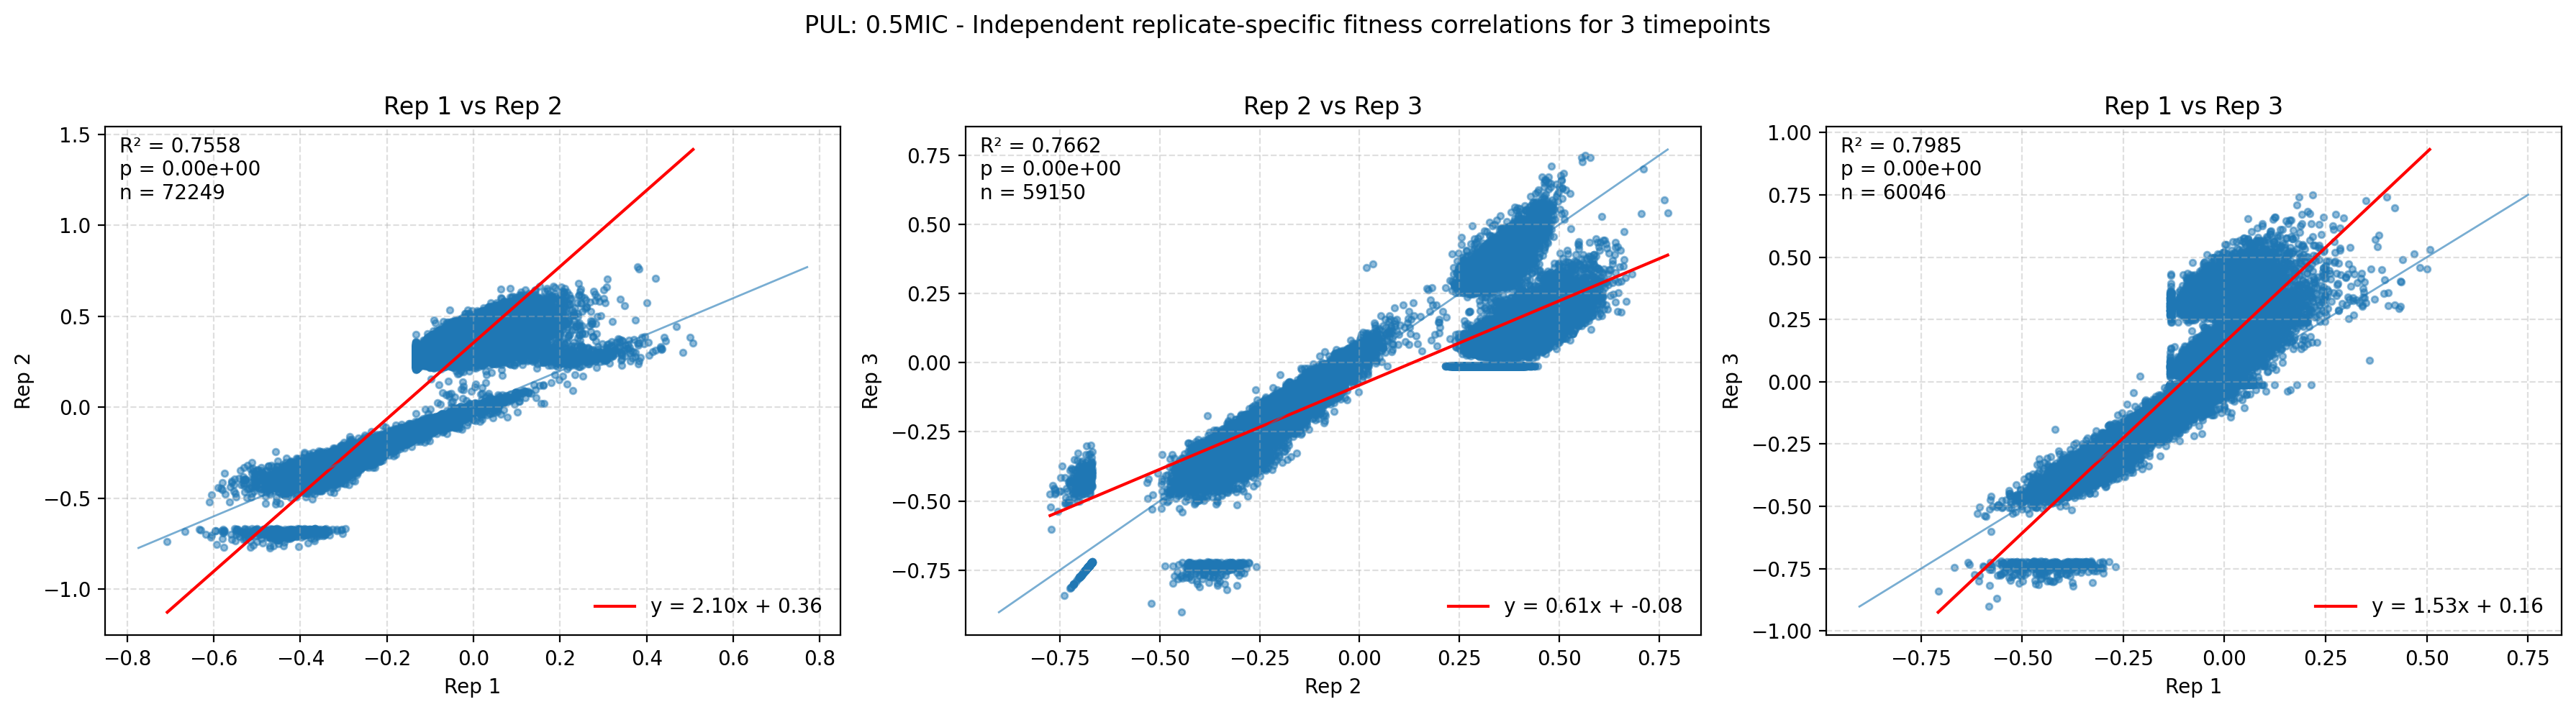

,Comparison,R,R²,p-value,slope,intercept,N
0,Rep 1 vs Rep 2,0.869362,0.755789,0.0,2.095790,0.355084,72249
1,Rep 2 vs Rep 3,0.875341,0.766221,0.0,0.609516,-0.080826,59150
2,Rep 1 vs Rep 3,0.893576,0.798478,0.0,1.529064,0.156992,60046


Saved figure to: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/3_phenotype_inference/plots/3rep_3tp_/scatter_indiv_vs_indiv_3panels.png


In [7]:
# Determine the standardized replicate labels used
rep1_label = [c for c in df1.columns if c != "ID"][0]
rep2_label = [c for c in df2.columns if c != "ID"][0]
rep3_label = [c for c in df3.columns if c != "ID"][0]

pairs = [
    (pair_12, rep1_label, rep2_label, f"{rep1_label} vs {rep2_label}"),
    (pair_23, rep2_label, rep3_label, f"{rep2_label} vs {rep3_label}"),
    (pair_13, rep1_label, rep3_label, f"{rep1_label} vs {rep3_label}"),
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), dpi=200, sharey=False)

results = []
for ax, (df_pair, xlab, ylab, title) in zip(axes, pairs):
    r, r2, p, slope, intercept, n = add_corr_scatter(
        ax=ax,
        df=df_pair,
        xcol=xlab,
        ycol=ylab,
        label_x=xlab,
        label_y=ylab,
        xlim=X_LIM,
        ylim=Y_LIM,
        show_eq=True
    )
    ax.set_title(title)
    results.append({
        "Comparison": title,
        "R": r,
        "R²": r2,
        "p-value": p,
        "slope": slope,
        "intercept": intercept,
        "N": n
    })

fig.suptitle("PUL: 0.5MIC - Independent replicate-specific fitness correlations for 3 timepoints", fontsize=12, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])

out_path = OUTPUT_DIR / "scatter_indiv_vs_indiv_3panels.png"
fig.savefig(out_path)
plt.show()

summary_df = pd.DataFrame(results)
display(summary_df)

print(f"Saved figure to: {out_path}")